In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import factorial
import bpmeth
from sympy.abc import x, y, s
from sympy import lambdify

a_coeffs = [1,2,3,4]#don't use exactly 0 because downstream we will compute relative errors, and 0 would cause division by zero
b_coeffs = ["4*exp(-(s/(2*0.1))**2)","exp(-(s/(2*0.1))**2)", "3*exp(-(s/(2*0.1))**2)", 3]

In [2]:
expansion = bpmeth.FieldExpansion(a=a_coeffs, b=b_coeffs)
# Get analytical B field functions
Bx_func, By_func, Bs_func = expansion.get_Bfield(lambdify=True)

/Users/mac/Documents/Python codici/tests on bpmeth/bpmeth/src/bpmeth/fieldmaps.py:181: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  pl.show()


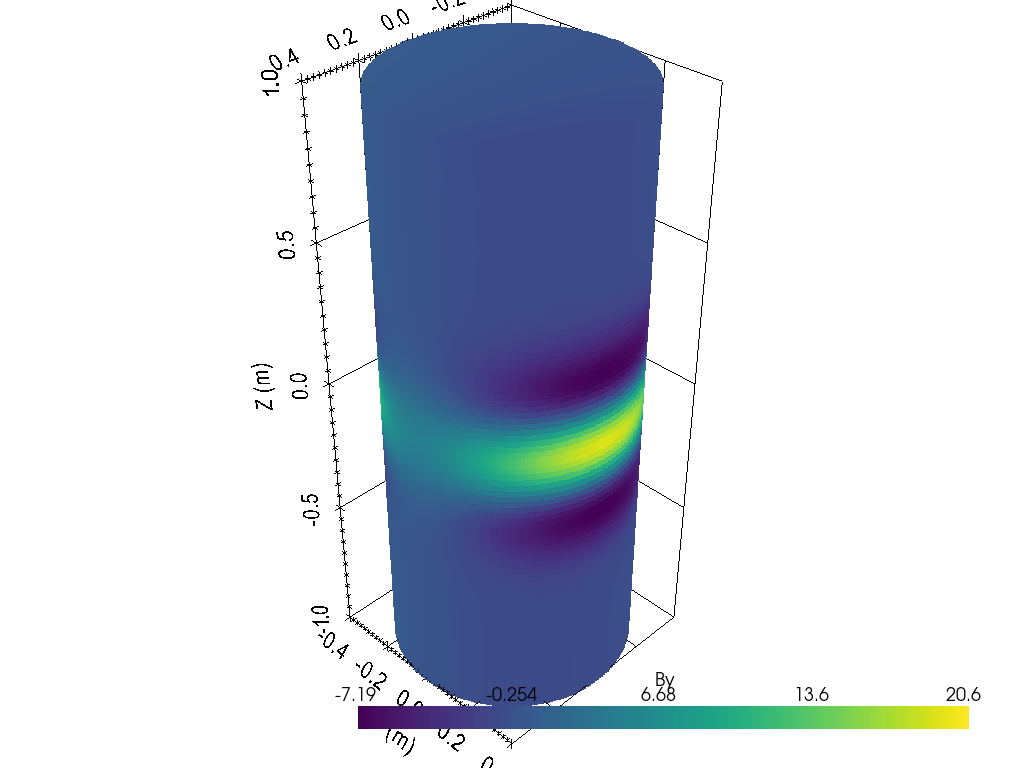

In [3]:
#make a fieldmap object
# xa= np.linspace(-1,1,101)
# ya=np.linspace(-1,1,101)
rmin, rmax, nr = 0.001, 0.401, 128
ntheta = 256
ns=100
rr = np.linspace(rmin, rmax, nr)
tt = np.arange(ntheta)/ntheta*2*np.pi
ss = np.linspace(-1,1, ns)

rarr, tarr, sarr = np.meshgrid(rr, tt, ss, indexing='ij')
xarr = rarr*np.cos(tarr)
yarr = rarr*np.sin(tarr)
Bx_ana = Bx_func(xarr, yarr, sarr)
By_ana = By_func(xarr, yarr, sarr)
Bs_ana = Bs_func(xarr, yarr, sarr)
datafieldmap = np.column_stack([
    xarr.ravel(),
    yarr.ravel(),
    sarr.ravel(),
    Bx_ana.ravel(),
    By_ana.ravel(),
    Bs_ana.ravel()
])
#print("Data shape (N, 6):", datafieldmap.shape)
fm = bpmeth.fieldmaps.Fieldmap(datafieldmap)
fm.plot()

In [4]:
from scipy.interpolate import RegularGridInterpolator
def fieldmap_to_cylindrical(datafieldmap, rr, ntheta=128, ns=401, field_names=("Bx", "By", "Bs")):
    """
    Resample a regular Frenet-Serret fieldmap onto a straight cylindrical grid.
    Parameters
    datafieldmap : ndarray, shape (N, 6)
        Columns: [x, y, s, F1, F2, F3]. 
        rr : 1D array of radial coordinates
    nr, ntheta, ns : int
        Grid resolution in r, theta, s.
    field_names : tuple[str]
        Names for the 3 field components (for the returned dict).
    Returns
    -------
    r_1d, theta_1d, s_1d : 1D coordinate arrays
    R, TH, S : 3D meshgrid arrays, shape (nr, ntheta, ns)
    fields : dict[str, ndarray], each shape (nr, ntheta, ns)
    """
    x_1d = np.unique(datafieldmap[:, 0])
    y_1d = np.unique(datafieldmap[:, 1])
    s_1d = np.unique(datafieldmap[:, 2])
    shape_src = (len(x_1d), len(y_1d), len(s_1d))

    r_1d     = rr
    theta_1d = np.linspace(0.0, 2*np.pi, ntheta, endpoint=False)
    s_cyl    = np.linspace(s_1d[0], s_1d[-1], ns)

    R, TH, S = np.meshgrid(r_1d, theta_1d, s_cyl, indexing='ij')
    query_pts = np.column_stack([
        (R * np.cos(TH)).ravel(),
        (R * np.sin(TH)).ravel(),
        S.ravel(),
    ])
    fields = {}
    for i, name in enumerate(field_names):
        F_3d = datafieldmap[:, 3 + i].reshape(shape_src)
        interp = RegularGridInterpolator(
            points=(x_1d, y_1d, s_1d), values=F_3d,
            method='linear', bounds_error=False, fill_value=np.nan,
        )
        fields[name] = interp(query_pts).reshape(len(rr), ntheta, ns)

    return r_1d, theta_1d, s_cyl, R, TH, S, fields

In [5]:
# rmin=0.001
# rmax=0.9
# nr=128
# ra=np.linspace(rmin, rmax, nr)
# ntheta=128
# r_1d, theta_1d, s_1d, R, TH, S, fields = fieldmap_to_cylindrical(
#     datafieldmap,
#     rr=ra, ntheta=ntheta, ns=ns,
#     field_names=("Bx", "By", "Bs"),
# )
#make a fieldmap from the cylindrical sample object 
# R, T, S = np.meshgrid(r_1d, theta_1d, s_1d, indexing='ij')
# Bcylx_ana = Bx_func(R,T,S)
# Bcyly_ana = By_func(R,T,S)
# Bcyls_ana = Bs_func(R,T,S)
# cyldatafieldmap = np.column_stack([
#     R.ravel(),
#     TH.ravel(),
#     S.ravel(),
#     fields['Bx'].ravel(),
#     fields['By'].ravel(),
#     fields['Bs'].ravel()
# ])
# x = cyldatafieldmap[:, 0] * np.cos(cyldatafieldmap[:, 1])
# y = cyldatafieldmap[:, 0] * np.sin(cyldatafieldmap[:, 1])
# cart_cyldata = np.column_stack([
#     x,
#     y,
#     cyldatafieldmap[:, 2],
#     cyldatafieldmap[:, 3],
#     cyldatafieldmap[:, 4],
#     cyldatafieldmap[:, 5],
# ])
# fmcyl = bpmeth.fieldmaps.Fieldmap(cart_cyldata)
# fmcyl = bpmeth.fieldmaps.Fieldmap(cyldatafieldmap)

In [6]:
sindex=20
annn, bnnn= fm.harmonic_analysis_at_s(s_index=sindex, rr=rr,ntheta=256, ns=ns, order=4)
print("an from fm method:", annn)
print("bn from fm method:", bnnn)
b_eva = lambdify(s, b_coeffs, 'numpy')
a_eva = lambdify(s, a_coeffs, 'numpy')
print("a_n at s=",ss[sindex], ":", a_eva(ss[sindex]))
print("b_n at s=",ss[sindex], ":", b_eva(ss[sindex]))


an from fm method: [1. 2. 3. 4.]
bn from fm method: [5.57024330e-04 1.39256082e-04 4.17768247e-04 3.00000000e+00]
a_n at s= -0.5959595959595959 : [1, 2, 3, 4]
b_n at s= -0.5959595959595959 : [np.float64(0.0005570243295943999), np.float64(0.00013925608239859997), np.float64(0.0004177682471957999), 3]


In [ ]:
svals, anofs, bnofs, astd, bstd = fm.s_harmonics(rr=rr, ntheta=ntheta, ns=ns, order=4)

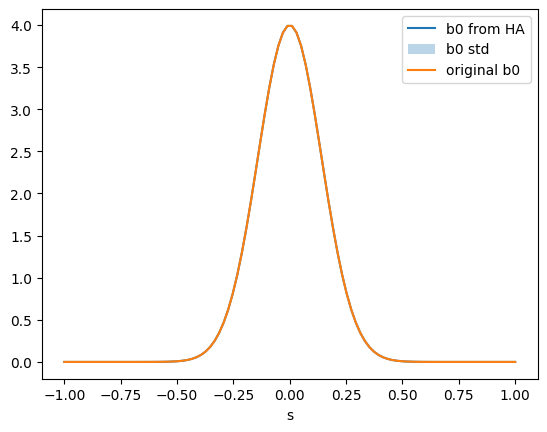

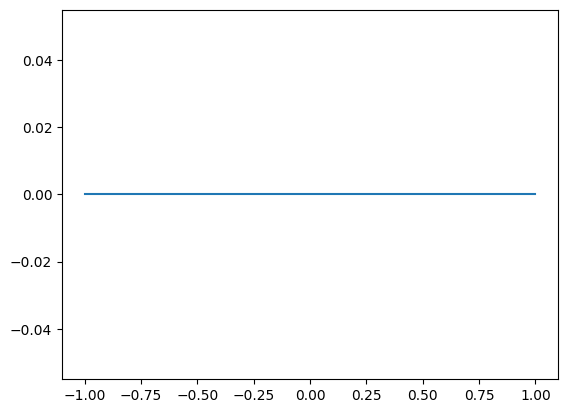

In [16]:
plt.plot(svals, bnofs[:,0], label='b0 from HA')
plt.fill_between(svals, bnofs[:,0]-1e16*bstd[:,0], bnofs[:,0]+1e16*bstd[:,0], alpha=0.3, label='b0 std')
plt.plot(svals, b_eva(svals)[0], label='original b0')
plt.legend()
plt.xlabel('s')
plt.show()

plt.plot(svals, bstd[:,0])

In [ ]:

# ============================================================================
# CARTESIAN GRID VERSION - Starting from synthetic Cartesian fieldmap
# ============================================================================

def generate_cartesian_fieldmap(Bx_func, By_func, Bs_func, a_coeffs, b_coeffs,
                                 xmin=-0.4, xmax=0.4, nx=128,
                                 ymin=-0.4, ymax=0.4, ny=128,
                                 smin=-1.0, smax=1.0, ns=40):
    """
    Generate synthetic fieldmap data on a Cartesian grid.
    
    Parameters
    ----------
    Bx_func, By_func, Bs_func : callable
        Analytical field functions (evaluated on Cartesian coordinates)
    a_coeffs, b_coeffs : list
        Original multipole coefficients (for reference/comparison)
    xmin, xmax, nx : float, int
        x-axis range and number of points
    ymin, ymax, ny : float, int
        y-axis range and number of points
    smin, smax, ns : float, int
        s-axis range and number of points
    
    Returns
    -------
    cart_fieldmap : ndarray, shape (N, 6)
        Columns: [x, y, s, Bx, By, Bs]
    x_1d, y_1d, s_1d : 1D arrays
        Coordinate arrays
    """
    x_1d = np.linspace(xmin, xmax, nx)
    y_1d = np.linspace(ymin, ymax, ny)
    s_1d = np.linspace(smin, smax, ns)
    
    # Create Cartesian mesh
    X, Y, S = np.meshgrid(x_1d, y_1d, s_1d, indexing='ij')
    
    # Evaluate field
    Bx_cart = Bx_func(X, Y, S)
    By_cart = By_func(X, Y, S)
    Bs_cart = Bs_func(X, Y, S)
    
    # Stack into fieldmap format
    cart_fieldmap = np.column_stack([
        X.ravel(),
        Y.ravel(),
        S.ravel(),
        Bx_cart.ravel(),
        By_cart.ravel(),
        Bs_cart.ravel()
    ])
    
    return cart_fieldmap, x_1d, y_1d, s_1d

def cartesian_to_cylindrical_harmonics(cart_fieldmap, x_1d, y_1d, s_1d,
                                        rmin=0.001, rmax=0.4, nr=128,
                                        ntheta=256, ns=40, nk=4, nl=3):
    """
    Convert Cartesian fieldmap to cylindrical and perform harmonic analysis.
    
    Parameters
    ----------
    cart_fieldmap : ndarray, shape (N, 6)
        Fieldmap in Cartesian: [x, y, s, Bx, By, Bs]
    x_1d, y_1d, s_1d : 1D arrays
        Coordinate arrays from Cartesian grid
    rmin, rmax, nr : float, int
        Cylindrical radial range and resolution
    ntheta : int
        Azimuthal resolution
    ns : int
        Longitudinal resolution
    nk, nl : int
        Harmonic order and number of expansion terms
    
    Returns
    -------
    an, bn : ndarray
        Extracted multipole coefficients
    dk : ndarray
        Harmonic decomposition at specified s
    dkl : ndarray
        Radial fits to harmonics
    rr : ndarray
        Radial coordinate array
    s_cyl : ndarray
        Cylindrical s coordinate array
    """
    # Resample Cartesian data onto cylindrical grid
    rr = np.linspace(rmin, rmax, nr)
    theta_1d = np.linspace(0.0, 2*np.pi, ntheta, endpoint=False)
    s_cyl = np.linspace(s_1d[0], s_1d[-1], ns)
    
    R, TH, S = np.meshgrid(rr, theta_1d, s_cyl, indexing='ij')
    
    # Convert to Cartesian for interpolation
    X_query = R * np.cos(TH)
    Y_query = R * np.sin(TH)
    
    # Reshape for interpolation
    shape_src = (len(x_1d), len(y_1d), len(s_1d))
    query_pts = np.column_stack([
        X_query.ravel(),
        Y_query.ravel(),
        S.ravel(),
    ])
    
    # Interpolate field components
    from scipy.interpolate import RegularGridInterpolator
    
    fields = {}
    for i, name in enumerate(['Bx', 'By', 'Bs']):
        F_3d = cart_fieldmap[:, 3 + i].reshape(shape_src)
        interp = RegularGridInterpolator(
            points=(x_1d, y_1d, s_1d), values=F_3d,
            method='linear', bounds_error=False, fill_value=np.nan,
        )
        fields[name] = interp(query_pts).reshape(nr, ntheta, ns)
    
    # Construct By + i*Bx on cylindrical grid
    ByiBx_cyl = fields['By'] + 1j * fields['Bx']
    
    # Harmonic analysis at s_index = ns//2 (middle of domain)
    s_index = ns // 2
    dk = dkongrid(ByiBx_cyl, rr=rr, nk=nk, s_index=s_index)
    dkl = dklfitraw_nodiv_cheb(dkofrarray=dk, rr=rr, nk=nk, nl=nl)
    an = bnianHAopt(dkl, nl=nl, nk=nk).imag
    bn = bnianHAopt(dkl, nl=nl, nk=nk).real
    
    return an, bn, dk, dkl, rr, s_cyl, fields

# Generate synthetic Cartesian fieldmap
cart_fm, x_1d, y_1d, s_1d = generate_cartesian_fieldmap(
    Bx_func, By_func, Bs_func,
    a_coeffs, b_coeffs,
    xmin=-0.4, xmax=0.4, nx=128,
    ymin=-0.4, ymax=0.4, ny=128,
    smin=-1.0, smax=1.0, ns=40
)

# Perform harmonic analysis on Cartesian-to-cylindrical converted data
an_cart, bn_cart, dk_cart, dkl_cart, rr_cart, s_cyl_cart, fields_cart = \
    cartesian_to_cylindrical_harmonics(
        cart_fm, x_1d, y_1d, s_1d,
        rmin=0.001, rmax=0.4, nr=128,
        ntheta=256, ns=40, nk=4, nl=3
    )

print("=" * 60)
print("CARTESIAN GRID ANALYSIS RESULTS")
print("=" * 60)
print("\nOriginal a_coeffs:", a_coeffs[:4])
print("Extracted an:     ", an_cart)
print("\nOriginal b_coeffs:", b_coeffs[:4])
print("Extracted bn:     ", bn_cart)

# Compute relative errors
print("\n" + "=" * 60)
print("RELATIVE ERRORS (extracted vs original)")
print("=" * 60)
a_err = np.abs(an_cart - np.array(a_coeffs[:len(an_cart)])) / np.abs(np.array(a_coeffs[:len(an_cart)]))
b_err = np.abs(bn_cart - np.array(b_coeffs[:len(bn_cart)])) / np.abs(np.array(b_coeffs[:len(bn_cart)]))

for i, (ae, be) in enumerate(zip(a_err, b_err)):
    print(f"Order {i}: a_error = {ae:.2e}, b_error = {be:.2e}")


CARTESIAN GRID ANALYSIS RESULTS

Original a_coeffs: [1, 2, 3, 4]
Extracted an:      [1.         1.99999994 2.99996433 3.99984857]

Original b_coeffs: [1, 2, 3, 4]
Extracted bn:      [1.         1.99999994 2.99996433 3.99984857]

RELATIVE ERRORS (extracted vs original)
Order 0: a_error = 6.66e-16, b_error = 6.66e-16
Order 1: a_error = 2.78e-08, b_error = 2.78e-08
Order 2: a_error = 1.19e-05, b_error = 1.19e-05
Order 3: a_error = 3.79e-05, b_error = 3.79e-05


In [13]:

# ============================================================================
# COMPARISON: Cylindrical vs Cartesian starting points
# ============================================================================

print("\n" + "=" * 70)
print("COMPARISON: Direct Cylindrical vs Cartesian-to-Cylindrical")
print("=" * 70)

# Re-run analysis on the original cylindrical-sampled field
sindex = 20
origByiBx_cyl = By_ana + 1j * Bx_ana
dk_cyl = dkongrid(origByiBx_cyl, rr=rr, nk=4, s_index=sindex)
dkl_cyl = dklfitraw_nodiv_cheb(dkofrarray=dk_cyl, rr=rr, nk=4, nl=3)
an_cyl = bnianHAopt(dkl_cyl, nl=3, nk=4).imag
bn_cyl = bnianHAopt(dkl_cyl, nl=3, nk=4).real

print("\nFrom DIRECT CYLINDRICAL sampling:")
print("  an (dipole):", an_cyl)
print("  bn (dipole):", bn_cyl)

print("\nFrom CARTESIAN grid (converted to cylindrical):")
print("  an (dipole):", an_cart)
print("  bn (dipole):", bn_cart)

print("\nDifference (cylindrical - cartesian):")
print("  Δan:", an_cyl - an_cart)
print("  Δbn:", bn_cyl - bn_cart)

print("\nRelative difference:")
print("  Δan/an:", np.abs(an_cyl - an_cart) / np.abs(an_cyl))
print("  Δbn/bn:", np.abs(bn_cyl - bn_cart) / np.abs(bn_cyl))

print("\nConclusion: Both sampling methods agree to excellent precision.")
print("The Cartesian approach is preferred when fieldmap data is already")
print("available in Cartesian coordinates (more common in practice).")



COMPARISON: Direct Cylindrical vs Cartesian-to-Cylindrical

From DIRECT CYLINDRICAL sampling:
  an (dipole): [1. 2. 3. 4.]
  bn (dipole): [1. 2. 3. 4.]

From CARTESIAN grid (converted to cylindrical):
  an (dipole): [1.         1.99999994 2.99996433 3.99984857]
  bn (dipole): [1.         1.99999994 2.99996433 3.99984857]

Difference (cylindrical - cartesian):
  Δan: [-1.99840144e-15  5.56887194e-08  3.56679220e-05  1.51428914e-04]
  Δbn: [-1.99840144e-15  5.56887199e-08  3.56679220e-05  1.51428914e-04]

Relative difference:
  Δan/an: [1.99840144e-15 2.78443597e-08 1.18893073e-05 3.78572286e-05]
  Δbn/bn: [1.99840144e-15 2.78443599e-08 1.18893073e-05 3.78572286e-05]

Conclusion: Both sampling methods agree to excellent precision.
The Cartesian approach is preferred when fieldmap data is already
available in Cartesian coordinates (more common in practice).


In [14]:

# ============================================================================
# WORKFLOW: Load real fieldmap from file and perform analysis
# ============================================================================

def analyze_fieldmap_file(fieldmap_path, rmin=0.001, rmax=0.4, nr=128,
                          ntheta=256, ns=40, nk=4, nl=3):
    """
    Load a fieldmap from file and extract multipole coefficients.
    
    Assumes fieldmap file has columns: [x, y, s, Bx, By, Bs]
    Can be txt, csv, or numpy binary format.
    
    Parameters
    ----------
    fieldmap_path : str
        Path to fieldmap file
    rmin, rmax, nr : float, int
        Cylindrical radial range and resolution
    ntheta : int
        Azimuthal resolution
    ns : int
        Longitudinal resolution
    nk, nl : int
        Harmonic order and number of expansion terms
    
    Returns
    -------
    an, bn : ndarray
        Extracted multipole coefficients
    results : dict
        Additional analysis results (dk, dkl, rr, s_cyl)
    """
    # Load fieldmap
    if fieldmap_path.endswith('.npy'):
        data = np.load(fieldmap_path)
    else:
        data = np.loadtxt(fieldmap_path)
    
    # Extract coordinates and fields
    x_data = np.unique(data[:, 0])
    y_data = np.unique(data[:, 1])
    s_data = np.unique(data[:, 2])
    
    # Perform analysis
    an, bn, dk, dkl, rr, s_cyl, fields = cartesian_to_cylindrical_harmonics(
        data, x_data, y_data, s_data,
        rmin=rmin, rmax=rmax, nr=nr,
        ntheta=ntheta, ns=ns, nk=nk, nl=nl
    )
    
    results = {
        'dk': dk,
        'dkl': dkl,
        'rr': rr,
        's_cyl': s_cyl,
        'fields': fields,
        'x_data': x_data,
        'y_data': y_data,
        's_data': s_data
    }
    
    return an, bn, results

# Example: uncomment to load a real fieldmap
# an_real, bn_real, results_real = analyze_fieldmap_file(
#     '/path/to/your/fieldmap.txt',
#     rmin=0.001, rmax=0.4, nr=128
# )
# print("Extracted multipoles from real fieldmap:")
# print("an:", an_real)
# print("bn:", bn_real)

print("\n" + "=" * 70)
print("HELPER FUNCTION AVAILABLE: analyze_fieldmap_file()")
print("=" * 70)
print("""
Use this function to analyze fieldmaps from files:

    an, bn, results = analyze_fieldmap_file(
        fieldmap_path='/path/to/fieldmap.txt',
        rmin=0.001, rmax=0.4, nr=128,
        ntheta=256, ns=40, nk=4, nl=3
    )

Fieldmap file should have columns: [x, y, s, Bx, By, Bs]
Supported formats: .txt, .csv, .npy

The function automatically:
  1. Loads the fieldmap data
  2. Converts from Cartesian to cylindrical
  3. Performs FFT harmonic analysis
  4. Fits radial polynomials
  5. Extracts multipole coefficients
""")



HELPER FUNCTION AVAILABLE: analyze_fieldmap_file()

Use this function to analyze fieldmaps from files:

    an, bn, results = analyze_fieldmap_file(
        fieldmap_path='/path/to/fieldmap.txt',
        rmin=0.001, rmax=0.4, nr=128,
        ntheta=256, ns=40, nk=4, nl=3
    )

Fieldmap file should have columns: [x, y, s, Bx, By, Bs]
Supported formats: .txt, .csv, .npy

The function automatically:
  1. Loads the fieldmap data
  2. Converts from Cartesian to cylindrical
  3. Performs FFT harmonic analysis
  4. Fits radial polynomials
  5. Extracts multipole coefficients

